In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [4]:
import torch

In [5]:
N = torch.zeros((27, 27, 27), dtype=torch.int32)

In [6]:
for w in words:
    chs = ['.' ] + ['.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        N[ix1, ix2, ix3] += 1

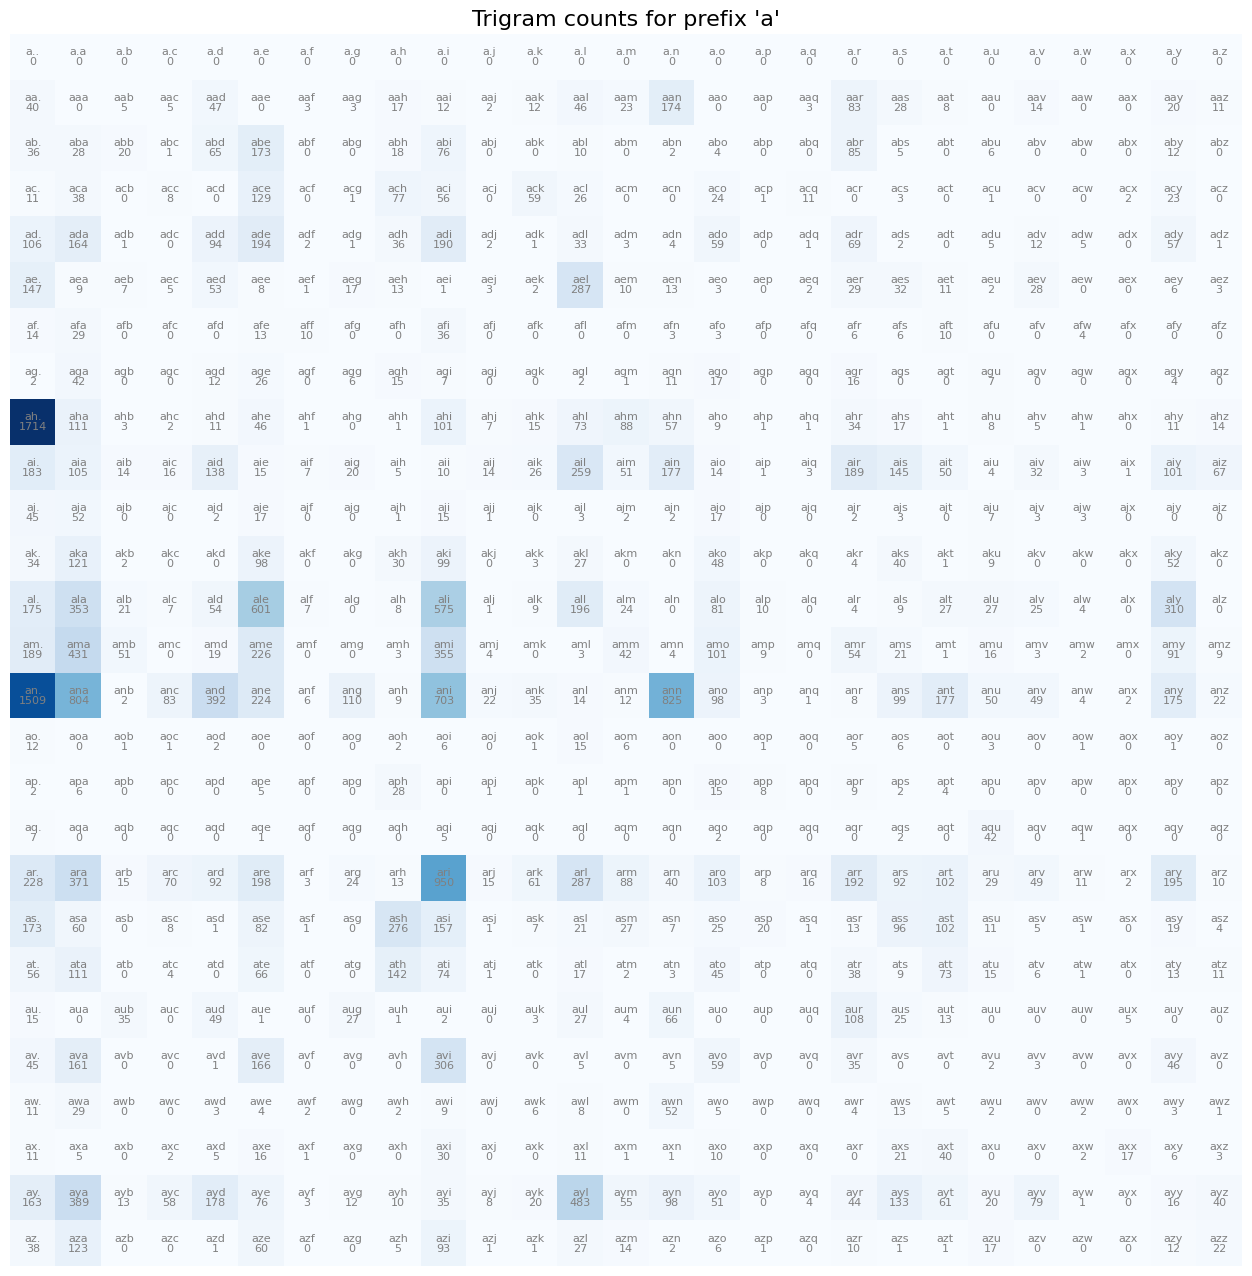

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

# Assuming N is your (27, 27, 27) tensor
char_to_view = 'a' # <--- Change this to any char (or '.' for start)
i = stoi[char_to_view]

plt.figure(figsize=(16,16))
plt.imshow(N[i], cmap='Blues')

for j in range(27):
    for k in range(27):
        # Trigram: ch1 (fixed) -> ch2 -> ch3
        chstr = itos[i] + itos[j] + itos[k]
        # We use k as x (columns) and j as y (rows)
        plt.text(k, j, chstr, ha="center", va="bottom", color='gray', fontsize=8)
        plt.text(k, j, int(N[i, j, k].item()), ha="center", va="top", color='gray', fontsize=8)

plt.title(f"Trigram counts for prefix '{char_to_view}'", fontsize=16)
plt.axis('off');

In [8]:
N[0, 0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [9]:
p = N[0, 0].float()

In [10]:
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

## Counting Based Approach

In [11]:
P = (N + 1).float()
P /= P.sum(2, keepdim=True)

In [12]:
P[0,0].sum().item()

1.0

In [13]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix1, ix2 = 0, 0
    while True:
        p = P[ix1, ix2]
        ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix3 == 0:
            break
        out.append(itos[ix3])
        ix1 = ix2
        ix2 = ix3
    print(''.join(out))

ce
bra
jalius
rochityharlonimittain
luwak


In [15]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.' ] + ['.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        prob = P[ix1, ix2, ix3]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-504653.)
nll=tensor(504653.)
2.2119739055633545


## Neural Network Based Approach

In [20]:
# Create the training set of trigrams (x, y)
xs, ys = [], []

for w in words[:1]:
    chs = ['.' ] + ['.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        print(ch1, ch2, ch3)
        xs.append([ix1, ix2])
        ys.append(ix3)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement() // 2
print('number of examples: ', num)


. . e
. e m
e m m
m m a
m a .
number of examples:  5


In [21]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()

xenc = xenc.view(-1, 54)

print(xenc.shape)

torch.Size([5, 54])


In [22]:
xs

tensor([[ 0,  0],
        [ 0,  5],
        [ 5, 13],
        [13, 13],
        [13,  1]])

In [23]:
ys

tensor([ 5, 13, 13,  1,  0])

In [24]:
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0.,

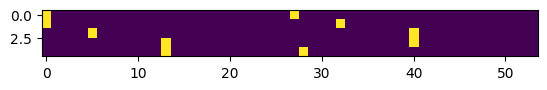

In [25]:
plt.imshow(xenc)

In [26]:
xenc.dtype

torch.float32

In [29]:
W = torch.randn((54, 1))
W.shape
# xenc @ W

torch.Size([54, 1])

In [32]:
## Actual Neural Network full

# Create the training set of trigrams (x, y)
xs, ys = [], []

for w in words:
    chs = ['.' ] + ['.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        # print(ch1, ch2, ch3)
        xs.append([ix1, ix2])
        ys.append(ix3)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = ys.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((54, 27), generator=g, requires_grad=True)

number of examples:  228146


In [57]:
## Propagation and Gradient Descent
loss_save = 0.0
for k in range(1000):

    #forward pass
    ## the inputs
    ### without indexing
    # xenc = F.one_hot(xs, num_classes=27).float().view(-1, 54)
    ## the wx + b
    # logits = xenc @ W
    ### with indexing
    logits = W[xs[:, 0]] + W[xs[:,1] + 27] 
    ## Activation function
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdim=True)
    # ## Calculating Loss
    # loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    # With Cross Entropy
    loss = F.cross_entropy(logits, ys)
    loss_save = loss

    # backward pass
    W.grad = None
    loss.backward()

    # update
    W.data += -30 * W.grad

loss_save


tensor(2.3364, grad_fn=<NllLossBackward0>)

In [58]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  
  out = []
  ix1, ix2 = 0, 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix1, ix2]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([[ix1, ix2]]), num_classes=27).float().view(-1, 54)
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    if ix == 0:
      break
    out.append(itos[ix])
    ix1 = ix2
    ix2 = ix
  print(''.join(out))

ce
braidallurailazitynnellin
jana
nallayn
ka
da
samiyaubrtthrigotai
morielliaugie
teda
kaleyla
